# 1. Foreword

![](https://i.imgur.com/OcSiuGJ.jpeg)

[Link to larger view where zoom is also available](https://i.imgur.com/OcSiuGJ.jpeg)

It was important for me to understand how the machine algorithm works and the DecisionTreeClassifier reveals part of its internal work as a simple **decision tree**. So when I selected features for it I always kept this graph in mind. I wanted to have very few features and soon I realized that **titles of Titanic passengers should be the key feature**! Why? It is known that most females survived and most males died, the only males who had good chances to survive on Titanic were boys and to sort them out we can use the **title Master which boys had in those days**.

When I had title as the key feature, I started to check if other features have correlations with it. I found out that the columns **Parch** (means number of parents / children aboard the Titanic) or **SibSp** (siblings / spouses) didn't influence survival chances of men and women. True that on average passengers travelling alone had worse chances to survive, but it's only because children and most women travelled with a family and children and women did survive. But **in separate groups of females, boys and men it didn't matter if you had a family or not**.

Looking for useful features, I also tried the **Fare** (ticket prices), but it turned out that **travel class correlates with chances to survie better than the price of a ticket** even if we categorize ticket prices into several groups.

One valuable feauture was already in the table and it was Embarked. **Passengers who embarked in Cherbourg** (these were mostly rich people) had better chances to survive and it also correlated with the chances to survive inside three title groups.

The last feature was the age. If we have boys in a separate group of Masters, then in two other groups the young age meant worse chances to survive and **people over 26 had better chances**.

At the end of this notebook we'll create the **decision tree**. If you want to explore this tree now, you can download it as **'tree_graph_default.gv.pdf'** from the **Output** of this notebook.

As **guidance** to read the tree:

*     Leaves with children show their splitting criterion on the top
*     The pair of values at the bottom show the count of False values and True values for the target respectively, of data points in that node of the tree.

**Example 1:**
1. At the top we have **Title** as the **splitting criterion** and we still have all passengers in the training set, **549** of them died, **342 survived**.
1. All passengers with titles 1 or 2 (aka females and boys) go to the left, here only 98 will die and 255 will survive. As the splitting criterion we have **Pclass (travel class)**.
1. Those who travelled in the third class go down and get **Embarked** as the splitting criterion.
1. Those who embarked in **Southampton** go to the right and get **Title** as the splitting criterion again.
1. **Masters** go to the right and we see that **13 of them died and 7 survived**, but the gini impurity is high and equals **0.455**, so we cannot predict precisely the outcome in the test model for this group of passengers (**Boys in the third class who embarked in Southampton**).

**Example 2:**
1. At the top we have **Title** as the **splitting criterion** and we still have all passengers in the training set, **549** of them died, **342 survived**.
1. All passengers with the title 3 (aka males) go to the right, here **451** will die and **87** survive. As the splitting criterion we have **Pclass**.
1. Those in the **second and third class** go further to the right and have **Age** as the splitting criterion.
1. Men who are **26 or younger** (age group 2) go to the right and have **Embarked** as the splitting criterion.
1. Those who embarked in Southampton or Queenstown go to the right and have **Pclass** as the splitting criterion again.
1. Those who travelled in **the second class** go down and we see that 25 of them died and only 1 survived. The gini impurity is low and equals **0.074**, so we can predict **precisely** the outcome in the test model for this group of passengers (**Young men in the second class who embarked in Southampton or Queenstown**).

In [1]:
import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))
import warnings
warnings.filterwarnings('ignore')

/kaggle/input/titanic/train.csv
/kaggle/input/titanic/test.csv
/kaggle/input/titanic/gender_submission.csv


# 2. Data preparation and categorization of values

We have two datasets: one to **train** the machine learning algorithm and another one to **test** it.

In [2]:
train_data = pd.read_csv("/kaggle/input/titanic/train.csv")
train_data.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [3]:
test_data = pd.read_csv("/kaggle/input/titanic/test.csv")
test_data.head()

,PassengerId,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,892,3,"Kelly, Mr. James",male,34.5,0,0,330911,7.8292,NaN,Q
1,893,3,"Wilkes, Mrs. James (Ellen Needs)",female,47.0,1,0,363272,7.0000,NaN,S
2,894,2,"Myles, Mr. Thomas Francis",male,62.0,0,0,240276,9.6875,NaN,Q
3,895,3,"Wirz, Mr. Albert",male,27.0,0,0,315154,8.6625,NaN,S
4,896,3,"Hirvonen, Mrs. Alexander (Helga E Lindqvist)",female,22.0,1,1,3101298,12.2875,NaN,S


On the graphs below we see that a **gender** and a **travel class** have a huge influence on whether a passenger survived. 

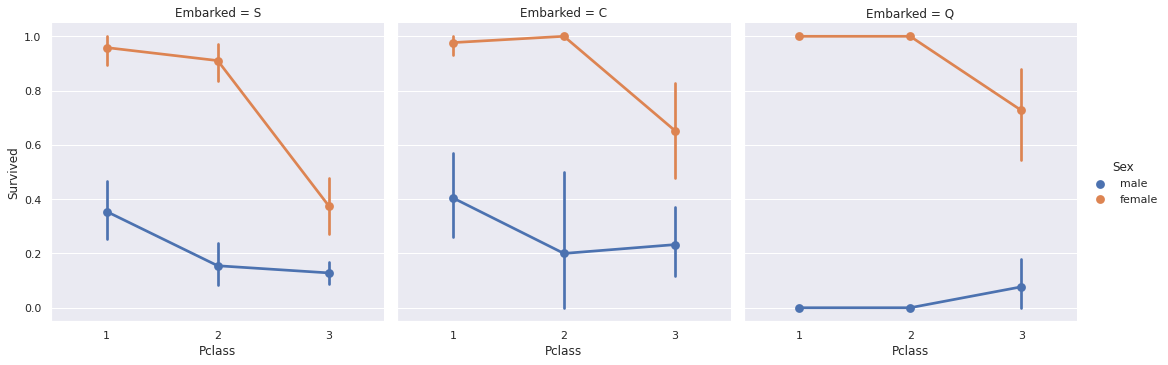

In [4]:
import matplotlib.pyplot as plt
%matplotlib inline
import seaborn as sns
sns.set()
sns.factorplot(x='Pclass', y='Survived', hue='Sex', col='Embarked', data=train_data)

In [5]:
def concat_df(train_data, test_data):
    # Returns a concatenated df of training and test set
    return pd.concat([train_data, test_data], sort=True).reset_index(drop=True)

In [6]:
train_test_data = concat_df(train_data, test_data)

In [7]:
# Extract titles from names
train_test_data['Title'] = train_test_data.Name.str.extract('([A-Za-z]+)\.')

In [8]:
pd.crosstab(train_test_data['Title'], train_test_data['Sex'])

Sex,female,male
Title,,
Capt,0,1
Col,0,4
Countess,1,0
Don,0,1
Dona,1,0
Dr,1,7
Jonkheer,0,1
Lady,1,0
Major,0,2


Our aim is to categorize **titles** into 3 bigger groups.

In [9]:
train_test_data['Title'] = train_test_data['Title'].replace('Mlle', 'Miss')
train_test_data['Title'] = train_test_data['Title'].replace('Ms', 'Miss')
train_test_data['Title'] = train_test_data['Title'].replace('Mme', 'Mrs')
train_test_data['Title'] = train_test_data['Title'].replace('Dona', 'Mrs')
train_test_data['Title'] = train_test_data['Title'].replace('Countess', 'Mrs')
train_test_data['Title'] = train_test_data['Title'].replace('Lady', 'Mrs')
train_test_data['Title'] = train_test_data['Title'].replace('Don', 'Mr')
train_test_data['Title'] = train_test_data['Title'].replace('Capt', 'Mr')
train_test_data['Title'] = train_test_data['Title'].replace('Col', 'Mr')
train_test_data['Title'] = train_test_data['Title'].replace('Don', 'Mr')
train_test_data['Title'] = train_test_data['Title'].replace('Dr', 'Mr')
train_test_data['Title'] = train_test_data['Title'].replace('Jonkheer', 'Mr')
train_test_data['Title'] = train_test_data['Title'].replace('Major', 'Mr')
train_test_data['Title'] = train_test_data['Title'].replace('Rev', 'Mr')
train_test_data['Title'] = train_test_data['Title'].replace('Sir', 'Mr')

In [10]:
train_test_data['Title'] = train_test_data['Title'].map({'Mrs': 1, 'Miss': 2, 'Master': 3, 'Mr': 4}).astype(int)

In [11]:
survived_by_title_pclass = round(train_test_data.groupby(['Title', 'Pclass']).mean()['Survived'], 2)

survived_by_title_pclass

Title  Pclass
1      1         0.98
       2         0.90
       3         0.50
2      1         0.96
       2         0.94
       3         0.50
3      1         1.00
       2         1.00
       3         0.39
4      1         0.36
       2         0.08
       3         0.11
Name: Survived, dtype: float64

We see that there is almost no difference in **survival rate** between **Mrs** and **Miss** and we can **merge** these two groups.

In [12]:
train_test_data['Title'] = train_test_data['Title'].map({1: 1, 2: 1, 3: 2, 4: 3}).astype(int)

In [13]:
survived_by_title_pclass = round(train_test_data.groupby(['Title', 'Pclass']).mean()['Survived'], 2)

survived_by_title_pclass

Title  Pclass
1      1         0.97
       2         0.92
       3         0.50
2      1         1.00
       2         1.00
       3         0.39
3      1         0.36
       2         0.08
       3         0.11
Name: Survived, dtype: float64

Now as we have titles we don't need to divide passengers into gender groups anymore. The **Master title is very important** and for the most passengers it referred to a boy. In contrast to other males, **boys had good chances to survive**. There were also a couple of crew members who had the title Master, but it's not easy to identify them since age values are missing.

In [14]:
train_test_data['Age'].isna().sum()

263

As in most cases Master meant a boy, we want to fill **missing age values** in this group with the **median value** and we apply the same rule to all title groups.

In [15]:
age_by_pclass_title = round(train_test_data.groupby(['Title', 'Pclass']).median()['Age'])

age_by_pclass_title

Title  Pclass
1      1         36.0
       2         28.0
       3         22.0
2      1          6.0
       2          2.0
       3          6.0
3      1         42.0
       2         30.0
       3         26.0
Name: Age, dtype: float64

In [16]:
train_test_data['Age'] = train_test_data.groupby(['Title', 'Pclass'])['Age'].apply(lambda x: x.fillna(round(x.median())))
train_test_data['Age'] = train_test_data['Age'].astype(int)

In [17]:
train_test_data.isna().sum()

Age               0
Cabin          1014
Embarked          2
Fare              1
Name              0
Parch             0
PassengerId       0
Pclass            0
Sex               0
SibSp             0
Survived        418
Ticket            0
Title             0
dtype: int64

In [18]:
# Filling the missing value in Fare with the median Fare of 3rd class alone passenger
med_fare = train_test_data.groupby(['Pclass', 'Parch', 'SibSp']).Fare.median()[3][0][0]
train_test_data['Fare'] = train_test_data['Fare'].fillna(med_fare)

Our next aim is to categorize **age values** into several big groups.

In [19]:
train_test_data['AgeBand'] = pd.qcut(train_test_data['Age'], 5)

In [20]:
count_by_title_age = train_test_data.groupby(['Title', 'AgeBand']).count()['PassengerId']

count_by_title_age

Title  AgeBand       
1      (-0.001, 21.0]    119
       (21.0, 26.0]      132
       (26.0, 30.0]       52
       (30.0, 40.0]       85
       (40.0, 80.0]       77
2      (-0.001, 21.0]     61
       (21.0, 26.0]        0
       (26.0, 30.0]        0
       (30.0, 40.0]        0
       (40.0, 80.0]        0
3      (-0.001, 21.0]    118
       (21.0, 26.0]      252
       (26.0, 30.0]      101
       (30.0, 40.0]      137
       (40.0, 80.0]      175
Name: PassengerId, dtype: int64

In [21]:
survived_by_title_age = round(train_test_data.groupby(['Title', 'AgeBand']).mean()['Survived'], 2)

survived_by_title_age

Title  AgeBand       
1      (-0.001, 21.0]    0.68
       (21.0, 26.0]      0.68
       (26.0, 30.0]      0.76
       (30.0, 40.0]      0.87
       (40.0, 80.0]      0.77
2      (-0.001, 21.0]    0.57
       (21.0, 26.0]       NaN
       (26.0, 30.0]       NaN
       (30.0, 40.0]       NaN
       (40.0, 80.0]       NaN
3      (-0.001, 21.0]    0.11
       (21.0, 26.0]      0.10
       (26.0, 30.0]      0.20
       (30.0, 40.0]      0.23
       (40.0, 80.0]      0.20
Name: Survived, dtype: float64

We can ignore the **Master** title which includes almost exclusively **boys** and if we look at titles 1 and 3 we can see that **people over 26 have better chances to survive**. 

In [22]:
train_test_data.loc[train_test_data['Age'] > 26, 'Fortunate_Age'] = 1
train_test_data.loc[train_test_data['Age'] <= 26, 'Fortunate_Age'] = 2
train_test_data['Fortunate_Age'] = train_test_data['Fortunate_Age'].astype(int)

In [23]:
count_by_title_fortunate = train_test_data.groupby(['Title', 'Fortunate_Age']).count()['PassengerId']

count_by_title_fortunate

Title  Fortunate_Age
1      1                214
       2                251
2      2                 61
3      1                413
       2                370
Name: PassengerId, dtype: int64

In [24]:
survived_by_title_fortunate = round(train_test_data.groupby(['Title', 'Fortunate_Age']).mean()['Survived'], 2)

survived_by_title_fortunate

Title  Fortunate_Age
1      1                0.81
       2                0.68
2      2                0.57
3      1                0.21
       2                0.11
Name: Survived, dtype: float64

In [25]:
# Fill two empty values in the 'Embarked' column with S as most passengers embarked in this port
train_test_data['Embarked'] = train_test_data['Embarked'].fillna('S')
train_test_data['Embarked'] = train_test_data['Embarked'].map({'C': 1, 'Q': 2, 'S': 3})

In [26]:
count_by_title_embarked = train_test_data.groupby(['Title', 'Embarked']).count()['PassengerId']

count_by_title_embarked

Title  Embarked
1      1           113
       2            60
       3           292
2      1            11
       2             5
       3            45
3      1           146
       2            58
       3           579
Name: PassengerId, dtype: int64

In [27]:
survived_by_title_embarked = round(train_test_data.groupby(['Title', 'Embarked']).mean()['Survived'], 2)

survived_by_title_embarked

Title  Embarked
1      1           0.88
       2           0.75
       3           0.69
2      1           1.00
       2           0.00
       3           0.58
3      1           0.27
       2           0.08
       3           0.15
Name: Survived, dtype: float64

# 3. Prepare tables for machine learning algorithms

In [28]:
# Drop features (columns) we don't need anymore
drop_cols = ['Age', 'Cabin', 'Fare', 'Name', 'Parch', 'Sex', 'SibSp', 'Ticket', 'AgeBand']

train_test_data.drop(columns=drop_cols, inplace=True)

In [29]:
train_data = train_test_data[train_test_data['Survived'].notna()]

In [30]:
train_data['Survived'] = train_data['Survived'].astype(int)

In [31]:
train_data.head()

,Embarked,PassengerId,Pclass,Survived,Title,Fortunate_Age
0,3,1,3,0,3,2
1,1,2,1,1,1,1
2,3,3,3,1,1,2
3,3,4,1,1,1,1
4,3,5,3,0,3,1


In [32]:
train_data.describe()

,Embarked,PassengerId,Pclass,Survived,Title,Fortunate_Age
count,891.000000,891.000000,891.000000,891.000000,891.000000,891.000000
mean,2.536476,446.000000,2.308642,0.383838,2.252525,1.510662
std,0.791503,257.353842,0.836071,0.486592,0.944637,0.500167
min,1.000000,1.000000,1.000000,0.000000,1.000000,1.000000
25%,2.000000,223.500000,2.000000,0.000000,1.000000,1.000000
50%,3.000000,446.000000,3.000000,0.000000,3.000000,2.000000
75%,3.000000,668.500000,3.000000,1.000000,3.000000,2.000000
max,3.000000,891.000000,3.000000,1.000000,3.000000,2.000000


In [33]:
test_data = train_test_data.drop(train_test_data[train_test_data.Survived >= 0].index)

In [34]:
test_data.head()

,Embarked,PassengerId,Pclass,Survived,Title,Fortunate_Age
891,2,892,3,NaN,3,1
892,3,893,3,NaN,1,1
893,2,894,2,NaN,3,1
894,3,895,3,NaN,3,1
895,3,896,3,NaN,1,2


In [35]:
test_data.describe()

,Embarked,PassengerId,Pclass,Survived,Title,Fortunate_Age
count,418.000000,418.000000,418.000000,0.0,418.000000,418.000000
mean,2.401914,1100.500000,2.265550,NaN,2.222488,1.543062
std,0.854496,120.810458,0.841838,NaN,0.949957,0.498739
min,1.000000,892.000000,1.000000,NaN,1.000000,1.000000
25%,2.000000,996.250000,1.000000,NaN,1.000000,1.000000
50%,3.000000,1100.500000,3.000000,NaN,3.000000,2.000000
75%,3.000000,1204.750000,3.000000,NaN,3.000000,2.000000
max,3.000000,1309.000000,3.000000,NaN,3.000000,2.000000


# 4. Getting model insights and saving results

In [36]:
# Importing Classifier Module
from sklearn.tree import DecisionTreeClassifier

In [37]:
y = train_data["Survived"]

features = ["Title", "Pclass", "Embarked","Fortunate_Age"]
X = train_data[features]
X_test = test_data[features]

model_default = DecisionTreeClassifier(random_state=10)
model_default.fit(X, y)
predictions = model_default.predict(X_test)

In [38]:
output = pd.DataFrame({'PassengerId': test_data.PassengerId, 'Survived': predictions})
output.to_csv('model_default.csv', index=False)
print("Your submission was successfully saved!")

Your submission was successfully saved!


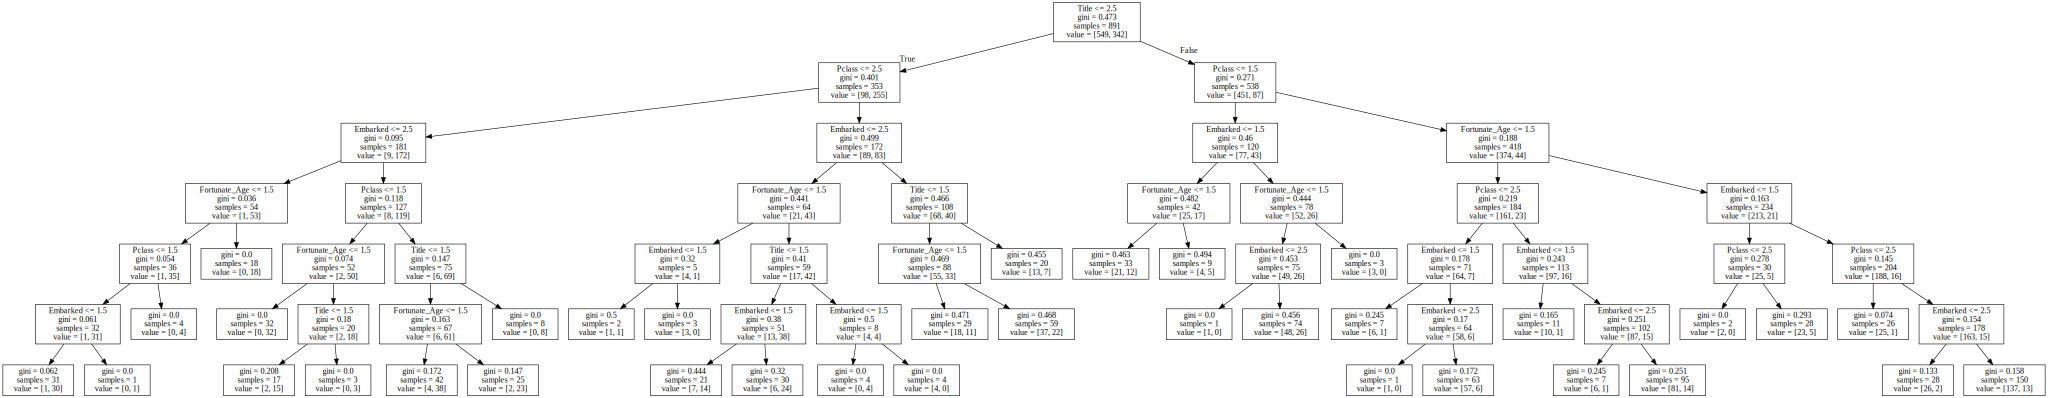

In [39]:
from sklearn import tree
import graphviz

tree_graph = tree.export_graphviz(model_default, out_file=None, feature_names=features)
graphviz.Source(tree_graph)

In [40]:
dot = graphviz.Source(tree_graph)
dot.render('tree_graph_default.gv', view=True)

'tree_graph_default.gv.pdf'

In [41]:
importances = pd.DataFrame({'feature':X.columns,'importance':np.round(model_default.feature_importances_,2)})
importances = importances.sort_values('importance',ascending=False).set_index('feature')
print(importances)

               importance
feature                  
Title                0.66
Pclass               0.25
Embarked             0.07
Fortunate_Age        0.02


In [42]:
# Calculate permutation importance
import eli5
from eli5.sklearn import PermutationImportance

perm = PermutationImportance(model_default, random_state=0).fit(X, y)
eli5.show_weights(perm, feature_names = X.columns.tolist())

Weight,Feature
0.1874 ± 0.0246,Title
0.1136 ± 0.0161,Pclass
0.0350 ± 0.0104,Embarked
0.0256 ± 0.0072,Fortunate_Age


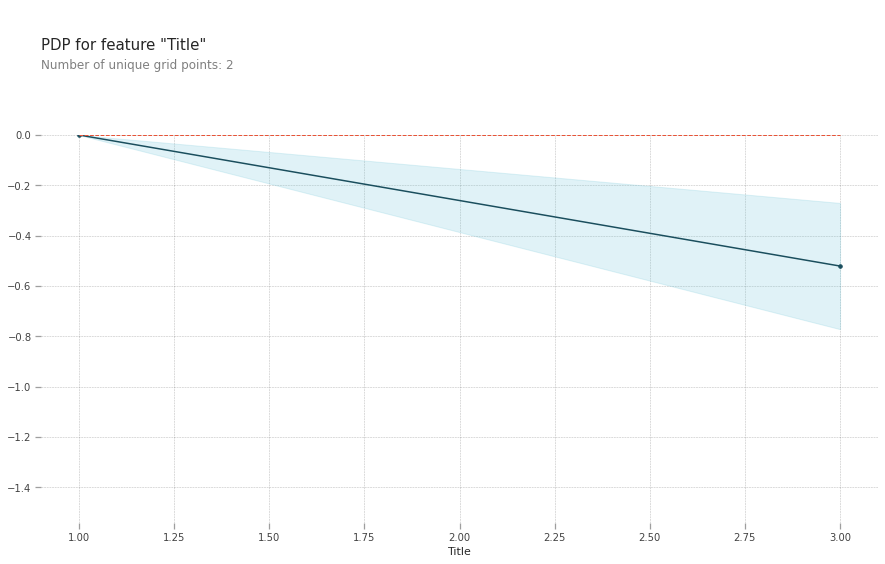

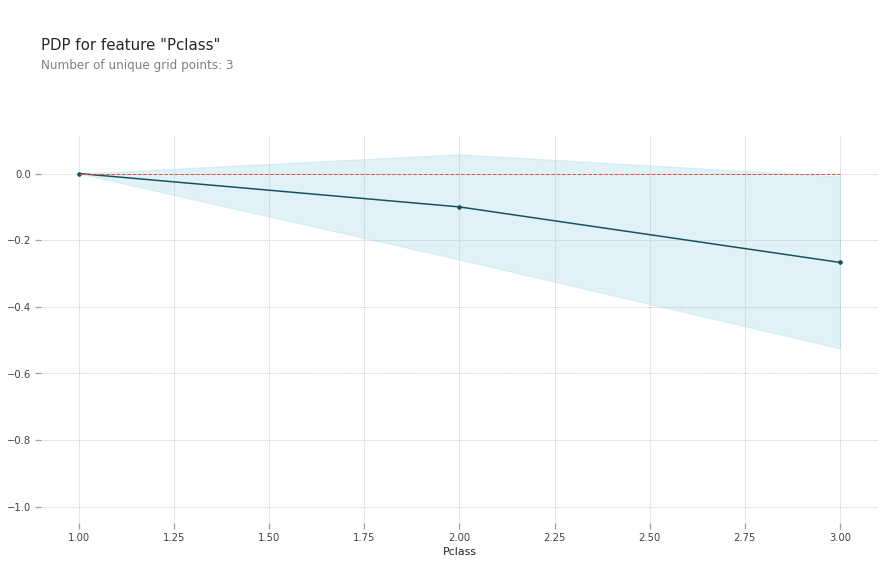

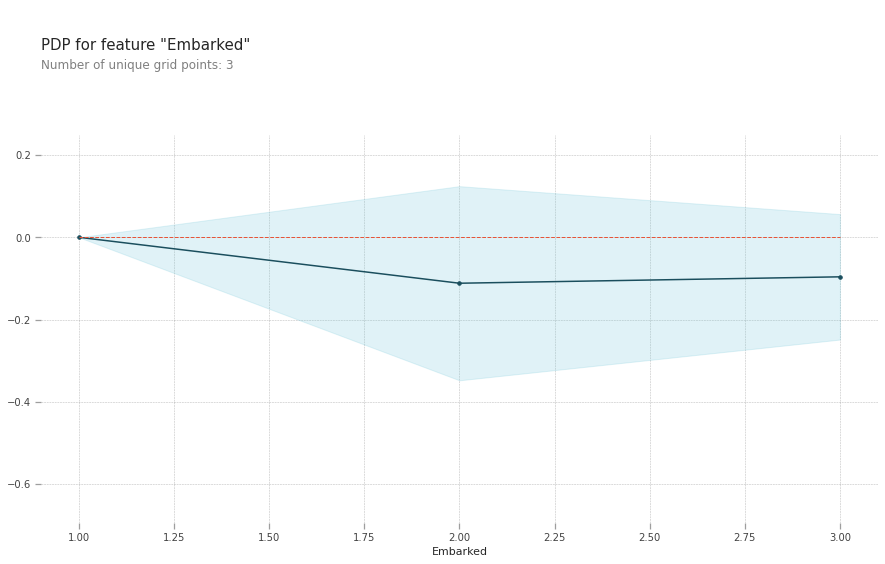

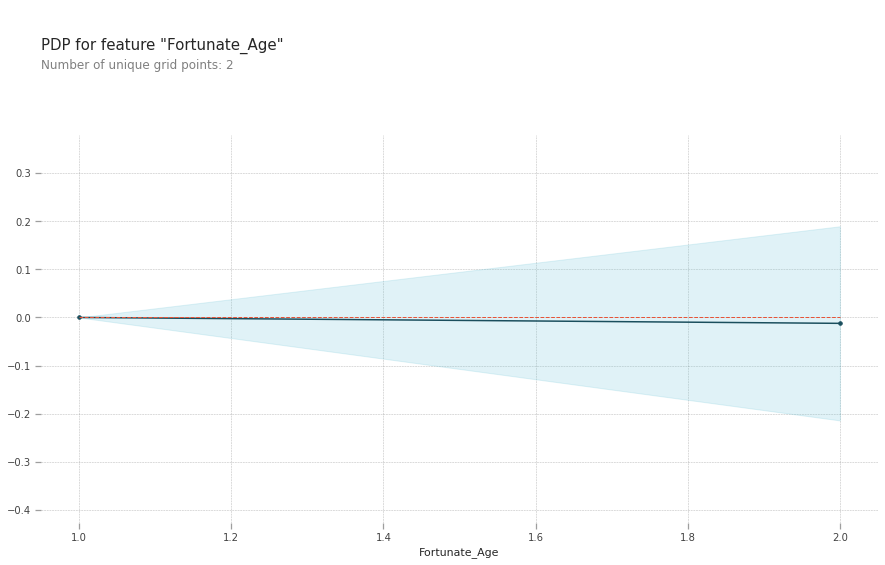

In [43]:
from pdpbox import pdp, get_dataset, info_plots

for feat_name in features:
    pdp_dist = pdp.pdp_isolate(model=model_default, dataset=train_data, model_features=features, feature=feat_name)
    pdp.pdp_plot(pdp_dist, feat_name)
    plt.show()

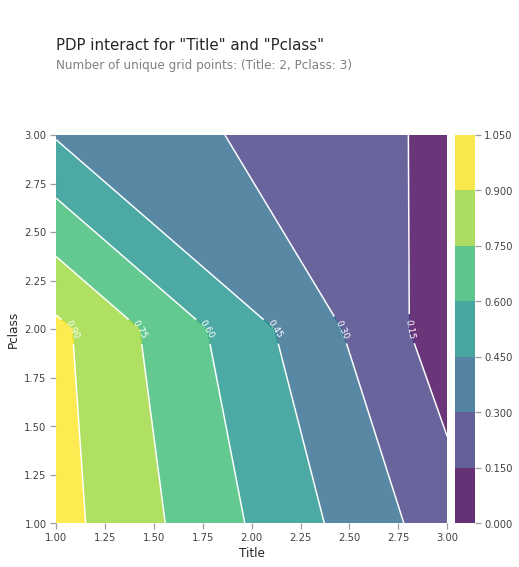

In [44]:
features_to_plot = ['Title', 'Pclass']
inter  =  pdp.pdp_interact(model=model_default, dataset=train_data, model_features=features, features=features_to_plot)

pdp.pdp_interact_plot(pdp_interact_out=inter, feature_names=features_to_plot, plot_type='contour')
plt.show()

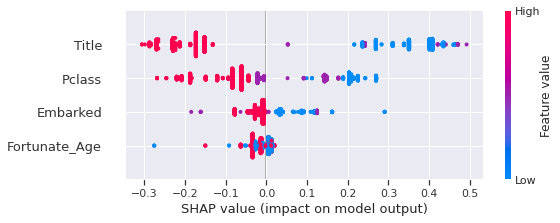

In [45]:
import shap  # package used to calculate Shap values

# Create object that can calculate shap values
explainer = shap.TreeExplainer(model_default)

# calculate shap values
shap_values = explainer.shap_values(X)

# Make plot
shap.summary_plot(shap_values[1], X)

On the Shap graph we see that "title 3 - males" (red dots) made a big impact on the output. The impact of the 3rd class is also visible (all red dots are on the left side). Passengers embarked in Southampton (red dots) are all on the left side too. The age had less distinct effect.

This DecisionTreeClassifier model scores almost 79% and it's several points better than a DecisionTreeClassifier which I run with more features before. This DecisionTreeClassifier scores exactly as many points as RandomForestClassifier with the same features, although RandomForestClassifier performs better in the Titanic competition and is usually the first choice. But from the very beginning I decided to fit my features for the DecisionTreeClassifier and this strategy worked well.